Càrrega de dades — llegir els fitxers Leipzig de train i test per a les 6 llengües

In [8]:
import os

DATA_DIR = 'langId'  # carpeta on són els fitxers

languages = ['eng', 'spa', 'deu', 'fra', 'ita', 'nld']

def load_corpus(filepath):
    """Llegeix un fitxer Leipzig i retorna una llista de frases."""
    sentences = []
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                sentences.append(parts[1])
    return sentences

train_data = {}
test_data  = {}

for lang in languages:
    train_data[lang] = load_corpus(os.path.join(DATA_DIR, f'{lang}_trn.txt'))
    test_data[lang]  = load_corpus(os.path.join(DATA_DIR, f'{lang}_tst.txt'))

train_data['eng']

['• • •',
 '0.00 0.00% How the mighty have fallen.',
 "0.00 0.00% Major companies coming out with their latest quarterly numbers include Dave & Buster's, Men's Wearhouse, Palo Alto Networks, Box, Barnes & Noble, Pep Boys-Manny, Moe & Jack, Ollie's Bargain Outlet, DavidsTea, Lululemon Athletica and Kroger.",
 '01 JANUARY 2015, MAGAZINE Why are there so many Magna Cartas?',
 '0:44 Now watching Up next 2016 Word Association with Brad Woodhouse The president of the Democratic American Bridge PAC on the GOP presidential field.',
 '0:46 autoplay autoplay Copy this code to your website or blog Searchers have found a second body in the aftermath of a large landslide in Sitka, Alaska, authorities said Thursday, and a third man remains missing and presumed dead.',
 '07:33: Building success The construction industry experienced an "extremely successful" end to 2014, according to a business survey.',
 '08:16: Milk crisis BBC Radio 4 National Farmers Union (NFU) president Meurig Raymond tells Today

Preprocessament — aplicar la funció de preprocessament a tot el corpus
- Eliminar els digits del text
- Convertir tot el text a minúscula
- Substitueix els espais en blanc continus per un de sol
- Concatena totes les frases amb un espai doble al mig

In [14]:
import re

def preprocess_sentence(text):
    text = re.sub(r'\d', '', text)        # 1. Eliminar dígits
    text = text.lower()                   # 2. Minúscules
    text = re.sub(r'\s+', ' ', text)      # 3. Espais múltiples → un sol
    return text.strip()

def preprocess_corpus(sentences):
    processed = [preprocess_sentence(s) for s in sentences]
    return '  '.join(processed)           # 4. Concatenar amb doble espai

train_corpus   = {lang: preprocess_corpus(train_data[lang]) for lang in languages}
test_sentences = {lang: [preprocess_sentence(s) for s in test_data[lang]] for lang in languages}

train_corpus['eng'][:500]

"• • •  . .% how the mighty have fallen.  . .% major companies coming out with their latest quarterly numbers include dave & buster's, men's wearhouse, palo alto networks, box, barnes & noble, pep boys-manny, moe & jack, ollie's bargain outlet, davidstea, lululemon athletica and kroger.  january , magazine why are there so many magna cartas?  : now watching up next word association with brad woodhouse the president of the democratic american bridge pac on the gop presidential field.  : autoplay a"

Entrenament — construir el model de trigrames per a cada llengua (amb min_freq=5)


REVISAR COM CALCULA B -> 256^3 x trigrames, ASCII -> num. de trigrames diferents que he trobat al corupus
N _> num. de caracters del corpus -2 (num de trigrames)

In [4]:
from nltk.collocations import TrigramCollocationFinder

def build_model(corpus_text, min_freq=5):
    finder = TrigramCollocationFinder.from_words(corpus_text)
    finder.apply_freq_filter(min_freq)
    freq_dict = dict(finder.ngram_fd)
    N = sum(freq_dict.values())  # total ocurrències
    B = len(freq_dict)           # vocabulari de trigrames
    return freq_dict, N, B

models = {}
for lang in languages:
    freq_dict, N, B = build_model(train_corpus[lang], min_freq=5)
    models[lang] = (freq_dict, N, B)

In [15]:
from sklearn.model_selection import KFold
import numpy as np

# Cross validation per trobar el lambda òptim
LAM_CANDIDATES = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
N_SPLITS = 5

def cv_find_best_lambda(train_data_text, languages_list, lam_candidates, n_splits=5, min_freq=5):
    """Trobar el lambda òptim via cross-validation"""
    
    from nltk import ngrams
    from collections import Counter
    import math
    
    # Dividir cada corpus per llenguatge en K folds
    cv_scores = {lam: [] for lam in lam_candidates}
    
    for lang in languages_list:
        # Dividir les oracions en K folds
        sentences = train_data[lang]
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        fold_indices = list(kf.split(sentences))
        
        for train_idx, val_idx in fold_indices:
            # Corpus d'entrenament (K-1 folds)
            train_sents = [sentences[i] for i in train_idx]
            train_text = preprocess_corpus(train_sents)
            
            # Corpus de validació (1 fold)
            val_sents = [sentences[i] for i in val_idx]
            val_text = preprocess_corpus(val_sents)
            
            # Construir model amb aquest fold
            freq_dict, N, B = build_model(train_text, min_freq=min_freq)
            
            # Probar cada lambda
            val_trigrams = Counter(ngrams(val_text, 3))
            for lam in lam_candidates:
                log_prob = 0.0
                for trigram, count_val in val_trigrams.items():
                    count_train = freq_dict.get(trigram, 0)
                    prob = (count_train + lam) / (N + lam * B)
                    log_prob += count_val * math.log(prob)
                cv_scores[lam].append(log_prob)
    
    # Calcular la mitjana de scores per a cada lambda
    avg_scores = {lam: np.mean(cv_scores[lam]) for lam in lam_candidates}
    best_lambda = max(avg_scores, key=avg_scores.get)
    
    print(f"Cross-validation results:")
    for lam in sorted(lam_candidates):
        print(f"  λ = {lam:.2f}: avg log-prob = {avg_scores[lam]:,.2f}")
    print(f"\n✓ Lambda òptim: {best_lambda}")
    
    return best_lambda, avg_scores

# Executar cross-validation
best_lambda, cv_results = cv_find_best_lambda(train_data, languages, LAM_CANDIDATES, n_splits=N_SPLITS)
LAM = best_lambda  # Actualitzar LAM amb el valor òptim

Cross-validation results:
  λ = 0.01: avg log-prob = -5,341,153.45
  λ = 0.05: avg log-prob = -5,333,359.28
  λ = 0.10: avg log-prob = -5,330,004.52
  λ = 0.20: avg log-prob = -5,326,653.57
  λ = 0.30: avg log-prob = -5,324,697.36
  λ = 0.50: avg log-prob = -5,322,242.08
  λ = 0.70: avg log-prob = -5,320,635.76
  λ = 1.00: avg log-prob = -5,318,951.12

✓ Lambda òptim: 1.0


Predicció — classificar cada frase del test set usant el λ òptim

Sintonització del paràmetre λ — trobar el valor òptim de Lidstone via K-fold cross-validation (K=5)

Probar candidats λ ∈ [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0] i seleccionar el que maximize avg log-prob

In [16]:
import math
from collections import Counter
from nltk import ngrams

# LAM ja establert per cross-validation

def score_document(doc_text, freq_dict, N, B, lam):
    doc_trigrams = Counter(ngrams(doc_text, 3))
    log_prob = 0.0
    for trigram, count_doc in doc_trigrams.items():
        count_train = freq_dict.get(trigram, 0)
        prob = (count_train + lam) / (N + lam * B)
        log_prob += count_doc * math.log(prob)
    return log_prob

def identify_language(doc_text, models, lam):
    scores = {lang: score_document(doc_text, *models[lang], lam) for lang in models}
    return max(scores, key=scores.get)

y_true, y_pred = [], []
for lang in languages:
    for sentence in test_sentences[lang]:
        y_true.append(lang)
        y_pred.append(identify_language(sentence, models, lam=LAM))

Avaluació — calcular accuracy i generar la matriu de confusió

Accuracy global: 99.88%


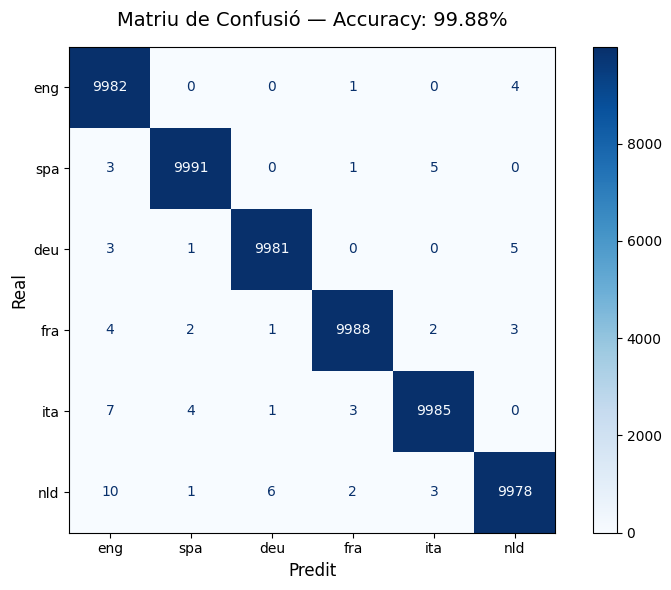

In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm  = confusion_matrix(y_true, y_pred, labels=languages)
acc = accuracy_score(y_true, y_pred)

print(f"Accuracy global: {acc*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=languages)
disp.plot(cmap='Blues', ax=ax, colorbar=True)

ax.set_title(f'Matriu de Confusió — Accuracy: {acc*100:.2f}%', fontsize=14, pad=15)
ax.set_xlabel('Predit', fontsize=12)
ax.set_ylabel('Real', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


Anàlisi — comentar els resultats: quines parelles de llengües es confonen més (p.ex., castellà-italià) i per qué (vocabulari i morfologia similars)